<a href="https://colab.research.google.com/github/Nightingales21/ICS1512-Machine-Learning-Labratory/blob/main/Experiment_1_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def perform_universal_eda_and_clean(df, target_column, is_classification=True):
    print("="*60)
    print(f"STARTING EDA & CLEANING FOR TARGET: '{target_column}'")
    print("="*60)

    # Create a copy to avoid modifying the original dataframe in place
    df_cleaned = df.copy()

    # 1. Shape & Initial Missing Value Analysis
    print(f"\n[1] Initial Dataset Shape: {df_cleaned.shape[0]} rows, {df_cleaned.shape[1]} columns\n")
    print("[2] Missing Values Analysis (Before Cleaning):")
    missing_data = df_cleaned.isnull().sum()
    total_missing = missing_data.sum()

    if total_missing > 0:
        print(missing_data[missing_data > 0])
        print(f"\n--> Total missing cells: {total_missing}. Starting automated imputation...")

        # Separating column types for target-safe handling
        num_cols = df_cleaned.select_dtypes(include=[np.number]).columns.tolist()
        cat_cols = df_cleaned.select_dtypes(exclude=[np.number]).columns.tolist()

        # Rule-based Imputation (Handling Missing Values)
        for col in df_cleaned.columns:
            if df_cleaned[col].isnull().sum() > 0:
                if col in num_cols:
                    # Impute numerical columns with Median
                    median_val = df_cleaned[col].median()
                    df_cleaned[col] = df_cleaned[col].fillna(median_val)
                    print(f"    Fixed Numerical feature '{col}': Imputed missing values with median ({median_val})")
                elif col in cat_cols:
                    # Impute categorical columns with Mode
                    mode_val = df_cleaned[col].mode()[0]
                    df_cleaned[col] = df_cleaned[col].fillna(mode_val)
                    print(f"    Fixed Categorical feature '{col}': Imputed missing values with mode ('{mode_val}')")
        print("--> All missing values successfully imputed!\n")
    else:
        print("No missing values detected. Skipping imputation pipeline.\n")

    # 2. Summary Statistics (CO1, K2)
    print("[3] Statistical Summary (Numerical Features Post-Cleaning):")
    print(df_cleaned.describe().T)

    # Update feature types for plotting
    num_cols = df_cleaned.select_dtypes(include=[np.number]).columns.tolist()
    cat_cols = df_cleaned.select_dtypes(exclude=[np.number]).columns.tolist()

    if target_column in num_cols:
        num_cols.remove(target_column)
    if target_column in cat_cols:
        cat_cols.remove(target_column)

    # --- VISUALIZATIONS ---
    sns.set_theme(style="whitegrid")

    # Plot 1: Target Variable Distribution
    plt.figure(figsize=(6, 4))
    if is_classification:
        sns.countplot(data=df_cleaned, x=target_column, palette="viridis")
        plt.title(f"Target Distribution: {target_column} (Classification)")
    else:
        sns.histplot(data=df_cleaned, x=target_column, kde=True, color="crimson")
        plt.title(f"Target Distribution: {target_column} (Regression)")
    plt.tight_layout()
    plt.show()

    # Plot 2: Numerical Feature Distributions (Histograms & Box Plots)
    if num_cols:
        num_features = len(num_cols)
        fig, axes = plt.subplots(num_features, 2, figsize=(12, 3 * num_features))
        if num_features == 1:
            axes = np.expand_dims(axes, axis=0)

        for i, col in enumerate(num_cols):
            sns.histplot(data=df_cleaned, x=col, kde=True, ax=axes[i, 0], color="skyblue")
            axes[i, 0].set_title(f"Distribution of {col}")

            sns.boxplot(data=df_cleaned, x=col, ax=axes[i, 1], color="lightgreen")
            axes[i, 1].set_title(f"Box Plot of {col}")

        plt.tight_layout()
        plt.show()

    # Plot 3: Relationship with Target (Scatter Plots or Box Plots)
    if num_cols:
        fig, axes = plt.subplots(1, min(3, len(num_cols)), figsize=(15, 4))
        if len(num_cols) == 1:
            axes = [axes]

        print("\n[4] Generating Feature-to-Target Relationships...")
        for i, col in enumerate(num_cols[:3]):
            if is_classification:
                sns.boxplot(data=df_cleaned, x=target_column, y=col, ax=axes[i], palette="pastel")
                axes[i].set_title(f"{col} by {target_column}")
            else:
                sns.scatterplot(data=df_cleaned, x=col, y=target_column, ax=axes[i], alpha=0.7)
                axes[i].set_title(f"{col} vs {target_column}")
        plt.tight_layout()
        plt.show()

    # Plot 4: Correlation Heatmap
    numeric_df = df_cleaned.select_dtypes(include=[np.number])
    if numeric_df.shape[1] > 1:
        plt.figure(figsize=(10, 8))
        corr_matrix = numeric_df.corr()
        sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
        plt.title("Correlation Matrix Heatmap")
        plt.tight_layout()
        plt.show()

    print("="*60)
    print("EDA PIPELINE & PROCESSING COMPLETE")
    print("="*60)

    return df_cleaned

STARTING EDA & CLEANING FOR TARGET: 'Species'

[1] Initial Dataset Shape: 150 rows, 6 columns

[2] Missing Values Analysis (Before Cleaning):
No missing values detected. Skipping imputation pipeline.

[3] Statistical Summary (Numerical Features Post-Cleaning):
               count       mean        std  min    25%    50%     75%    max
Id             150.0  75.500000  43.445368  1.0  38.25  75.50  112.75  150.0
SepalLengthCm  150.0   5.843333   0.828066  4.3   5.10   5.80    6.40    7.9
SepalWidthCm   150.0   3.054000   0.433594  2.0   2.80   3.00    3.30    4.4
PetalLengthCm  150.0   3.758667   1.764420  1.0   1.60   4.35    5.10    6.9
PetalWidthCm   150.0   1.198667   0.763161  0.1   0.30   1.30    1.80    2.5


/tmp/ipykernel_4497/2544551404.py:64: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_cleaned, x=target_column, palette="viridis")


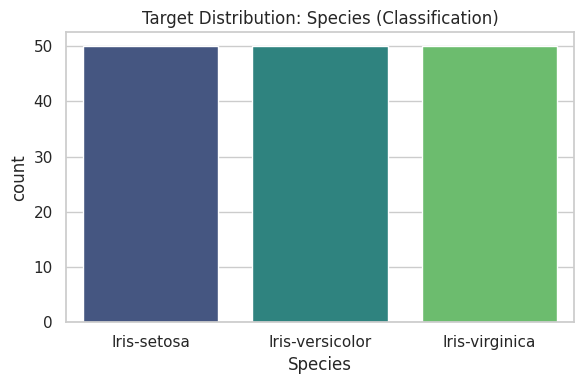

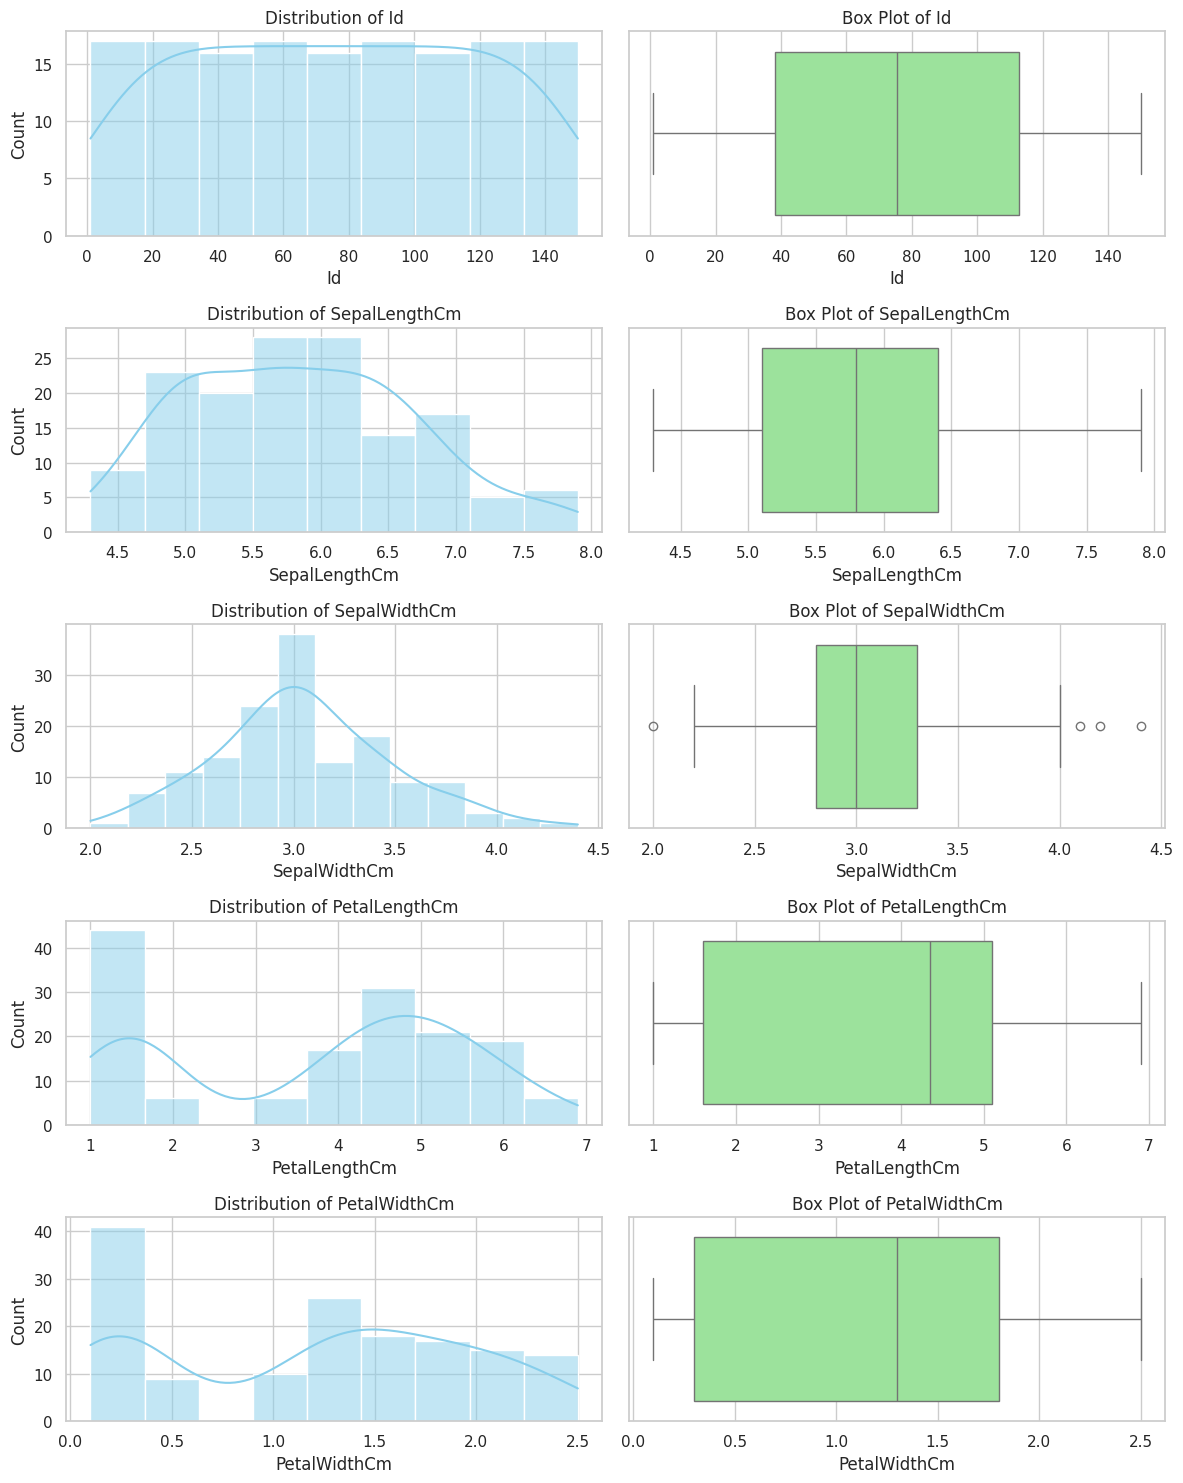


[4] Generating Feature-to-Target Relationships...


/tmp/ipykernel_4497/2544551404.py:98: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_cleaned, x=target_column, y=col, ax=axes[i], palette="pastel")
/tmp/ipykernel_4497/2544551404.py:98: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_cleaned, x=target_column, y=col, ax=axes[i], palette="pastel")
/tmp/ipykernel_4497/2544551404.py:98: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_cleaned, x=target_column, y=col, ax=axes[i], palette="pastel")


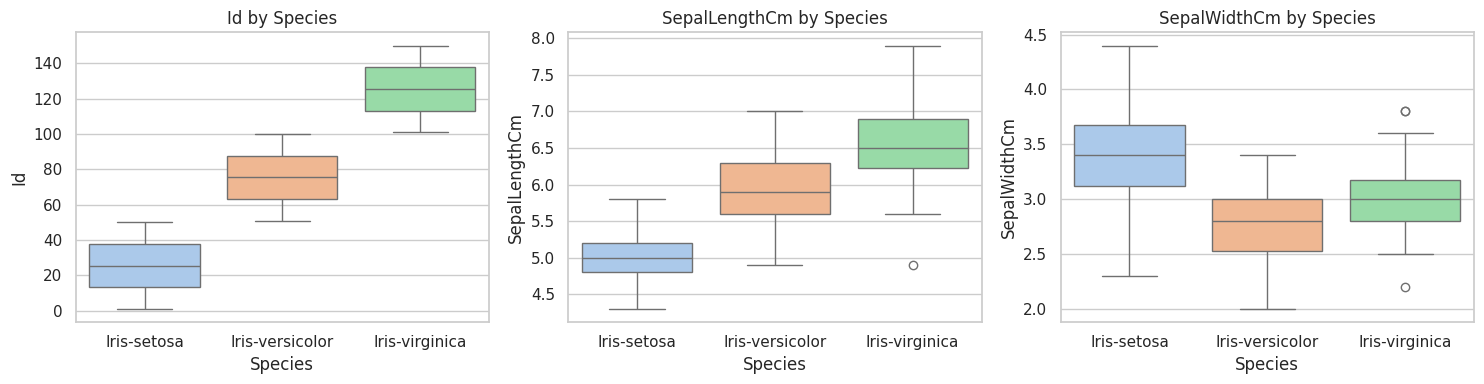

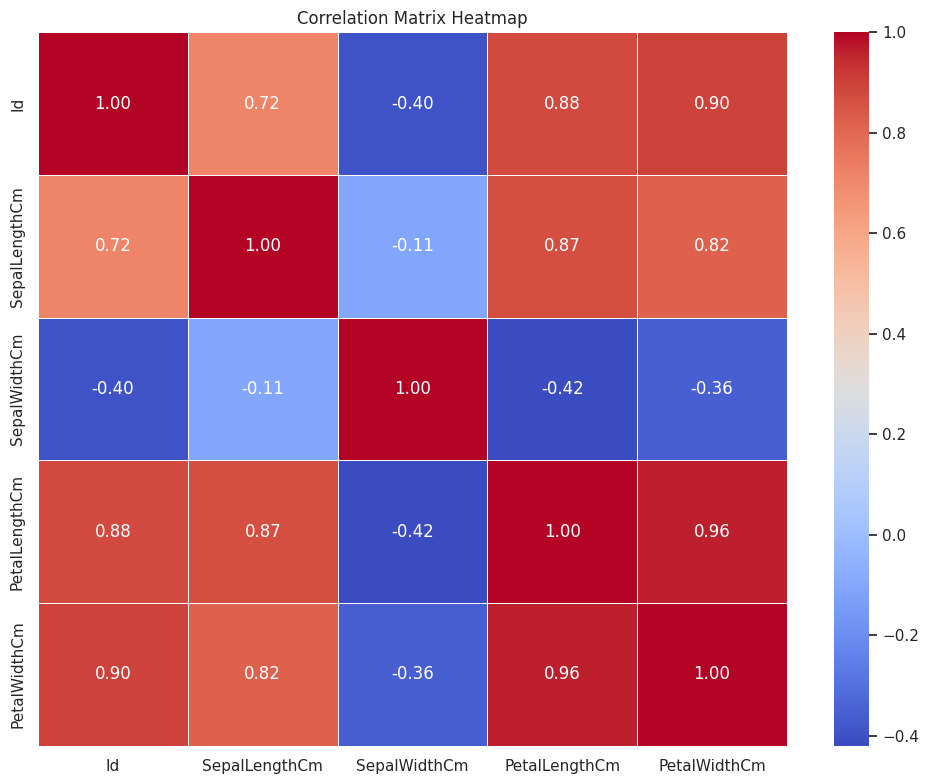

EDA PIPELINE & PROCESSING COMPLETE
      Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm  \
0      1            5.1           3.5            1.4           0.2   
1      2            4.9           3.0            1.4           0.2   
2      3            4.7           3.2            1.3           0.2   
3      4            4.6           3.1            1.5           0.2   
4      5            5.0           3.6            1.4           0.2   
..   ...            ...           ...            ...           ...   
145  146            6.7           3.0            5.2           2.3   
146  147            6.3           2.5            5.0           1.9   
147  148            6.5           3.0            5.2           2.0   
148  149            6.2           3.4            5.4           2.3   
149  150            5.9           3.0            5.1           1.8   

            Species  
0       Iris-setosa  
1       Iris-setosa  
2       Iris-setosa  
3       Iris-setosa  
4       Iris-s

/tmp/ipykernel_4497/2544551404.py:64: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_cleaned, x=target_column, palette="viridis")


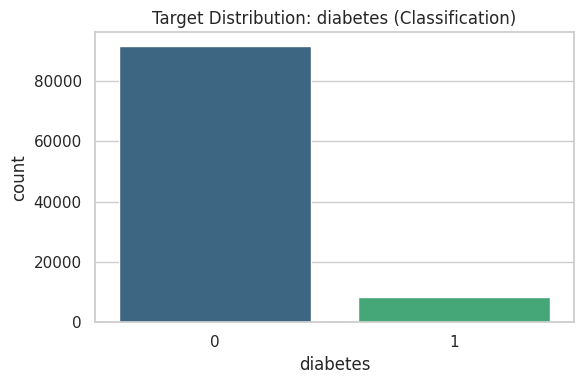

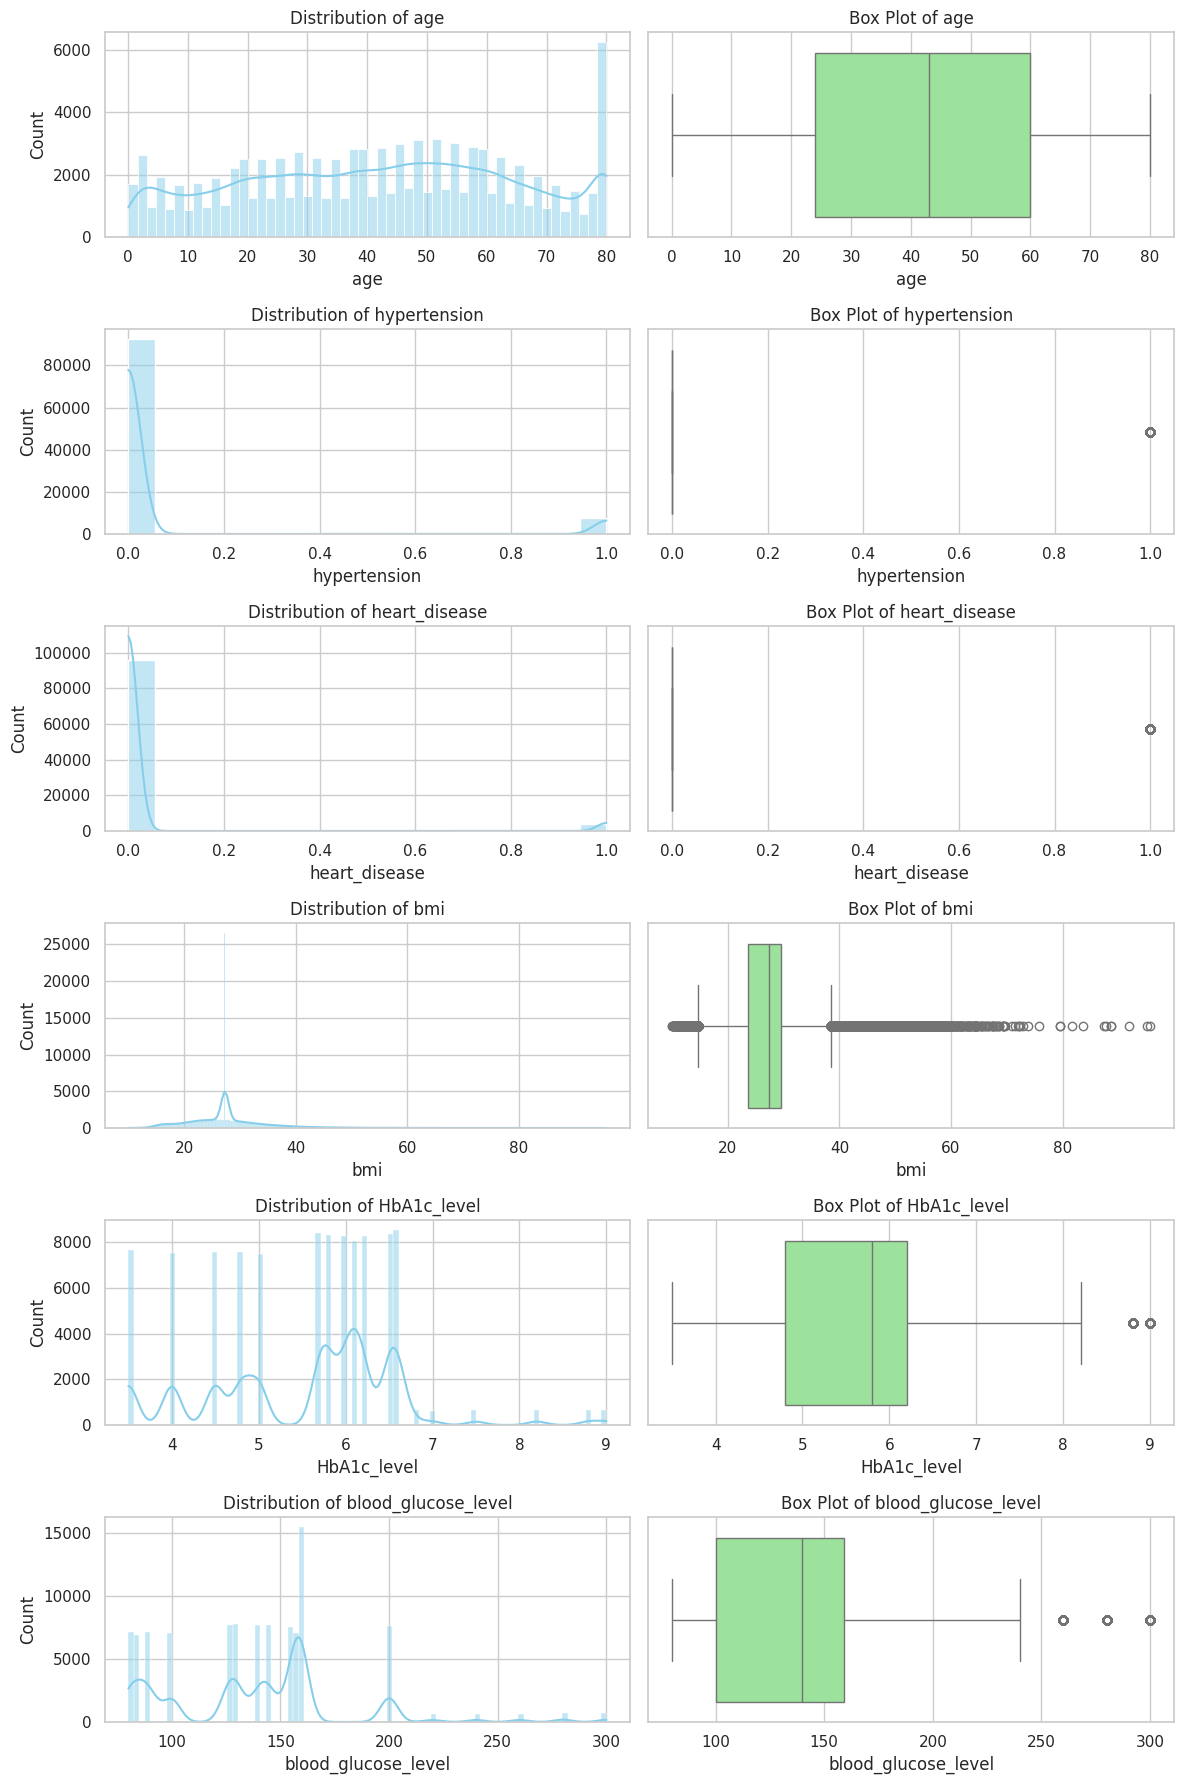


[4] Generating Feature-to-Target Relationships...


/tmp/ipykernel_4497/2544551404.py:98: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_cleaned, x=target_column, y=col, ax=axes[i], palette="pastel")
/tmp/ipykernel_4497/2544551404.py:98: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_cleaned, x=target_column, y=col, ax=axes[i], palette="pastel")
/tmp/ipykernel_4497/2544551404.py:98: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_cleaned, x=target_column, y=col, ax=axes[i], palette="pastel")


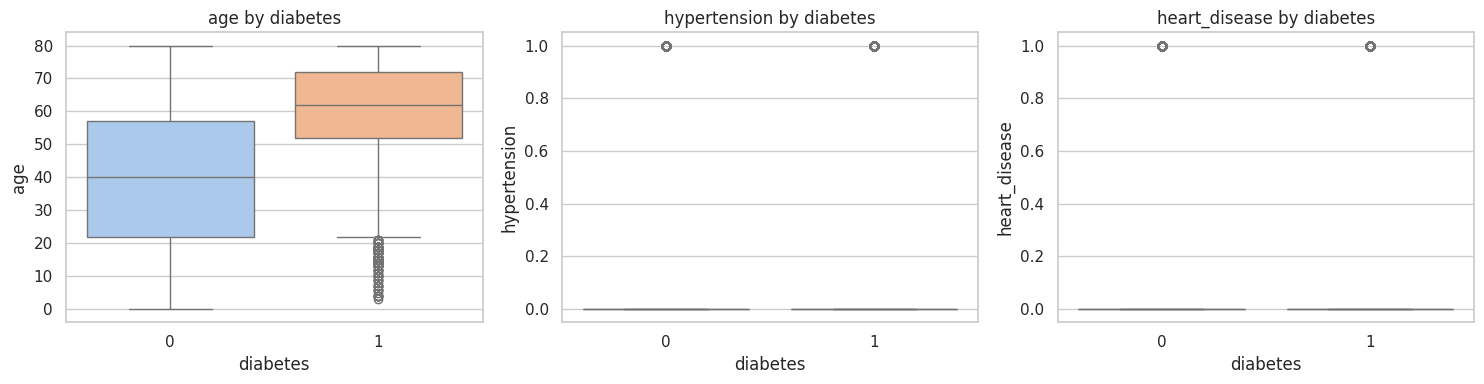

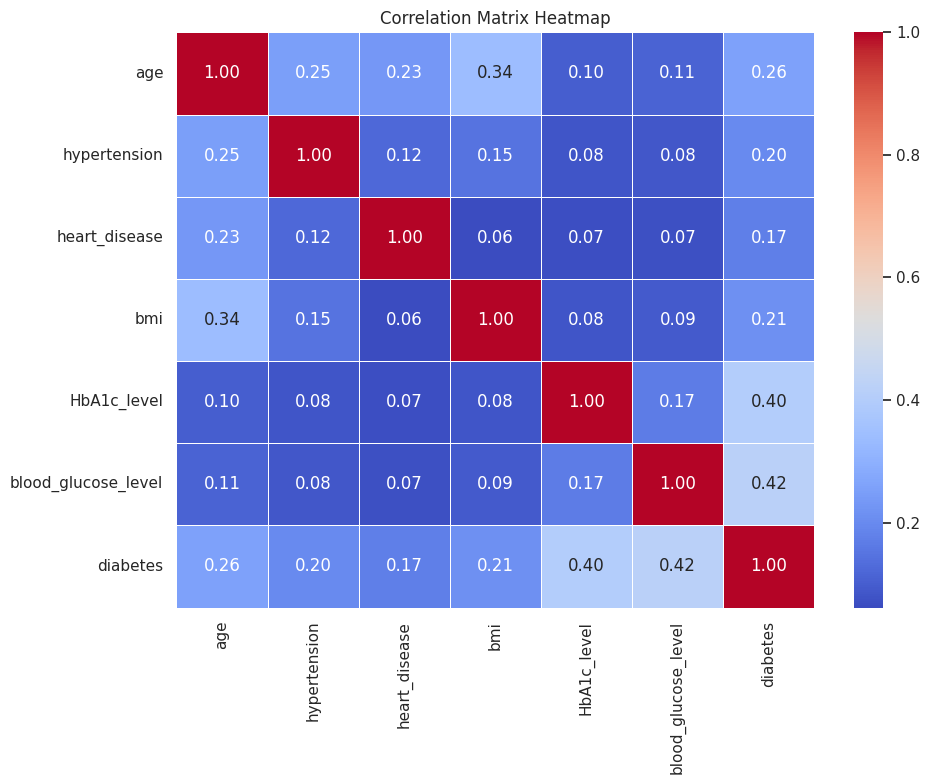

EDA PIPELINE & PROCESSING COMPLETE
       gender   age  hypertension  heart_disease smoking_history    bmi  \
0      Female  80.0             0              1           never  25.19   
1      Female  54.0             0              0         No Info  27.32   
2        Male  28.0             0              0           never  27.32   
3      Female  36.0             0              0         current  23.45   
4        Male  76.0             1              1         current  20.14   
...       ...   ...           ...            ...             ...    ...   
99995  Female  80.0             0              0         No Info  27.32   
99996  Female   2.0             0              0         No Info  17.37   
99997    Male  66.0             0              0          former  27.83   
99998  Female  24.0             0              0           never  35.42   
99999  Female  57.0             0              0         current  22.43   

       HbA1c_level  blood_glucose_level  diabetes  
0           

ValueError: Could not interpret value `label` for `x`. An entry with this name does not appear in `data`.

<Figure size 600x400 with 0 Axes>

In [5]:
datasets = ["Iris.csv", "diabetes_prediction_dataset.csv", "emails.csv", "written_name_train.csv"]
targets =  ['Species', 'diabetes', 'label', 'gender']
for i in range(0, 4):
  df = pd.read_csv(datasets[i])
  df_cleaned = perform_universal_eda_and_clean(df, targets[i], True)

  print(df)
  print(df_cleaned)